# Simulation of Masked Diffusion Equation

This notebook simulates the equation:
$$\frac{1}{\sqrt{L}} \sum_{j \neq i} \left( \frac{1}{\sqrt{L}} \sum_{\mu=1}^{M} x_i^{\mu} x_j^{\mu} (1 - m_j^t) x_j^{\mu} \right)$$

With:
- $m_j^t \sim \mathrm{Bernoulli}(t)$
- $x_j^{\mu} \sim \pm 1$ with probability $1/2$

In [1]:
using Random, Statistics, Distributions
using Plots
using StatsBase

## Define Simulation Function

In [2]:
"""
    simulate_equation(L, M, t)

Simulate the masked diffusion equation once.

# Arguments:
- L: number of neurons
- M: number of features
- t: Bernoulli parameter for mask m_j^t

# Returns:
- result: array of results for each neuron i
"""
function simulate_equation(L::Int, M::Int, t::Float64)
    # Sample x_j^μ ∈ {-1, +1} for all j and μ
    x = rand([-1, 1], L, M)  # L neurons, M features
    x[1,1]=1.
    
    # Sample m_j^t ~ Bernoulli(t) for all j
    m = rand(Bernoulli(t), L)
    m[1]=1.

    sum = 0.0
        
    # Sum over j ≠ i=1
    for j in 1:L
        # Sum over μ ≠ 1
        
        for μ in 1:M
            sum += x[1, μ] * x[j, μ] * (1 - m[j]) * x[j, 1]
        end
    end    
    return sum / L
end

println("Function defined successfully")

Function defined successfully


In [10]:
function simulate_equation(L::Int, M::Int, t::Float64, m_t::Float64)
        # Sample x_j^μ ∈ {-1, +1} for all j and μ
        x = rand([-1, 1], L, M)  # L neurons, M features
        x[1,1]=1.
        
        # Calculate number of indices for C_t and E_t
        num_indices_C_t = Int(round(L * (1 - t + m_t) / 2))
        num_indices_E_t = Int(round(L * (1 - t - m_t) / 2))
        
        # Draw C_t and E_t indices (excluding index 1)
        available_indices = 2:L
        C_t = sample(available_indices, min(num_indices_C_t, length(available_indices)), replace=false)
        E_t = sample(setdiff(available_indices, C_t), min(num_indices_E_t, length(available_indices) - length(C_t)  ), replace=false)
        
        sum = 0.0
            
        # Sum over indices in C_t (positive contribution)
        for j in C_t
            for μ in 1:M
                sum += x[1, μ] * x[j, μ] * x[j, 1]
            end
        end
        
        # Sum over indices in E_t (negative contribution)
        for j in E_t
            for μ in 1:M
                sum -= x[1, μ] * x[j, μ] * x[j, 1]
            end
        end
        
        return sum / L
    end


simulate_equation (generic function with 2 methods)

## Run Simulations

In [18]:
# Parameters
L = 2000          # Number of neurons
M = 200           # Number of features/dimensions
t_values = 0.1:0.1:0.5  # Bernoulli parameters
n_simulations = 1000  # Number of simulation runs
m_t = 0.2  # Mask parameter

println("L (neurons): $L")
println("M (features): $M")
println("t values: $t_values")
println("Number of simulations: $n_simulations")
println("Mask parameter m_t: $m_t")

L (neurons): 2000
M (features): 200
t values: 0.1:0.1:0.5
Number of simulations: 1000
Mask parameter m_t: 0.2


In [19]:
# Store results for each t value
simulations_by_t = Dict()

for t in t_values
    println("\nSimulating for t = $t...")
    
    # Run simulations
    all_results = []
    for sim in 1:n_simulations
        result = simulate_equation(L, M, t,m_t)
        push!(all_results, result)
    end
    
    # Store results
    simulations_by_t[t] = all_results
    
    # Compute statistics
    all_values = vcat(all_results...)
    mean_val = mean(all_values)
    std_val = std(all_values)
    
    println("  Mean: $(round(mean_val, digits=4))")
    println("  Std:  $(round(std_val, digits=4))")
    println("  Min:  $(round(minimum(all_values), digits=4))")
    println("  Max:  $(round(maximum(all_values), digits=4))")
end

println("\n✓ All simulations completed!")


Simulating for t = 0.1...
  Mean: 0.1951
  Std:  0.2947
  Min:  -0.651
  Max:  1.058

Simulating for t = 0.2...
  Mean: 0.2124
  Std:  0.2958
  Min:  -0.678
  Max:  1.099

Simulating for t = 0.3...
  Mean: 0.212
  Std:  0.261
  Min:  -0.586
  Max:  1.103

Simulating for t = 0.4...
  Mean: 0.1876
  Std:  0.2374
  Min:  -0.59
  Max:  0.928

Simulating for t = 0.5...
  Mean: 0.2002
  Std:  0.2285
  Min:  -0.447
  Max:  0.97

✓ All simulations completed!


## Analyze Results

In [8]:
# Compute summary statistics for each t
t_means = []
t_stds = []

for t in sort(collect(keys(simulations_by_t)))
    all_values = vcat(simulations_by_t[t]...)
    push!(t_means, mean(all_values))
    push!(t_stds, std(all_values))
end

println("\nSummary by t value:")
for (t, mean_val, std_val) in zip(sort(collect(keys(simulations_by_t))), t_means, t_stds)
    println("t = $(round(t, digits=1)): μ = $(round(mean_val, digits=4)), σ = $(round(std_val, digits=4))")
end


Summary by t value:
t = 0.1: μ = 0.3011, σ = 0.2972
t = 0.2: μ = 0.3087, σ = 0.2745
t = 0.3: μ = 0.3025, σ = 0.2577
t = 0.4: μ = 0.3057, σ = 0.2448
t = 0.5: μ = 0.3084, σ = 0.2248


## Visualize Results

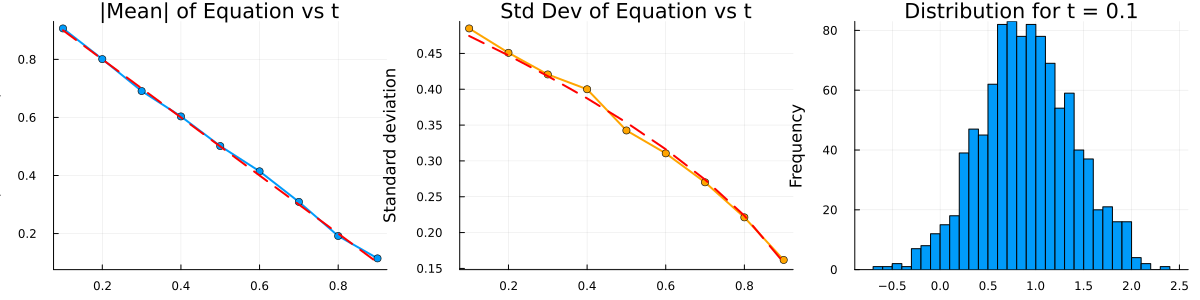

In [97]:
# Plot 1: Mean vs t
tvals = sort(collect(keys(simulations_by_t)))

p1 = plot(tvals, t_means, 
    title="|Mean| of Equation vs t",
    xlabel="Bernoulli parameter t",
    ylabel="|Mean value|",
    marker=:circle,
    linewidth=2,
    legend=false)
    plot!(tvals, (1 .- tvals),
        label="1-t", linewidth=2, linestyle=:dash, color=:red)

# Plot 2: Standard deviation vs t
p2 = plot(tvals, t_stds,
    title="Std Dev of Equation vs t",
    xlabel="Bernoulli parameter t",
    ylabel="Standard deviation",
    marker=:circle,
    color=:orange,
    linewidth=2,
    legend=false)
plot!(tvals, sqrt.(M/L  .*(1 .- tvals)),
        label="1-t", linewidth=2, linestyle=:dash, color=:red)


t_0=collect(keys(simulations_by_t))[end]
middle_t = sort(collect(keys(simulations_by_t)))[div(length(t_values), 2)]

t=0.1

p3 = histogram(vcat(simulations_by_t[t]...),
    title="Distribution for t = $(round(t, digits=1))",
    xlabel="Value",
    ylabel="Frequency",
    bins=30,
    legend=false)

plot(p1, p2, p3, layout=(1,3), size=(1200, 300))

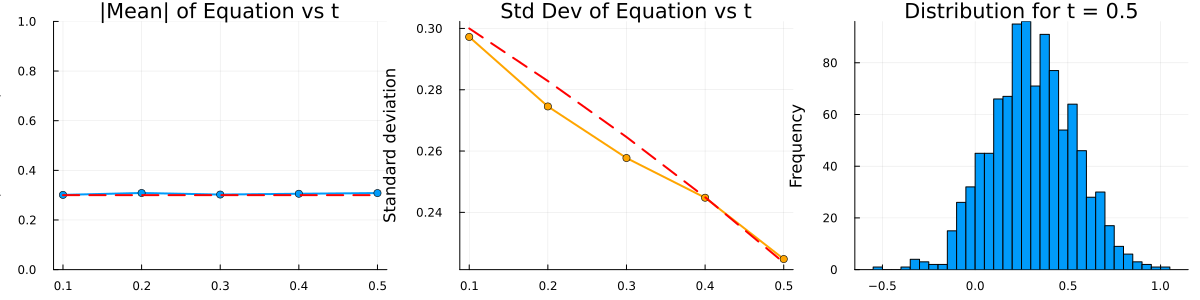

In [17]:
# Plot 1: Mean vs t
tvals = sort(collect(keys(simulations_by_t)))

p1 = plot(tvals, t_means, 
    title="|Mean| of Equation vs t",
    xlabel="Bernoulli parameter t",
    ylabel="|Mean value|",
    marker=:circle,
    linewidth=2,
    legend=false,
    ylims=(0, 1))
    plot!(tvals, ones(size(tvals)) .* m_t,
        label="1-t", linewidth=2, linestyle=:dash, color=:red)

c_t = (1 .- tvals .+ m_t)/2
e_t = (1 .- tvals .- m_t)/2

# Plot 2: Standard deviation vs t
p2 = plot(tvals, t_stds,
    title="Std Dev of Equation vs t",
    xlabel="Bernoulli parameter t",
    ylabel="Standard deviation",
    marker=:circle,
    color=:orange,
    linewidth=2,
    legend=false)
plot!(tvals, sqrt.(M/L  .*(1 .-tvals)),
        label="1-t", linewidth=2, linestyle=:dash, color=:red)

t_0=collect(keys(simulations_by_t))[end]
middle_t = sort(collect(keys(simulations_by_t)))[div(length(t_values), 2)]

t=0.5

p3 = histogram(vcat(simulations_by_t[t]...),
    title="Distribution for t = $(round(t, digits=1))",
    xlabel="Value",
    ylabel="Frequency",
    bins=30,
    legend=false,
    )

plot(p1, p2, p3, layout=(1,3), size=(1200, 300))